# Statistical Analysis of Student Performance
**Author:** *Bassel Darwesh*


## 1. Introduction and Motivation
Understanding the factors that influence student academic performance is crucial for educational research. 
In this notebook, we investigate whether demographic factors (specifically gender and parental education level) have a statistically significant impact on student scores in Mathematics and Language.

## 2. Data Description
The dataset contains performance records of 486 students. The variables include:
* `student_id`: Nominal identifier.
* `gender`: Nominal categorical (male, female).
* `parental.level.of.education`: Ordinal categorical (high school, associate's, bachelor's, master's).
* `math` & `language`: Metric/continuous variables (scores from 0-100).

In [12]:
import pandas as pd
import numpy as np

# Load the data, telling pandas to use the semicolon as the separator
df = pd.read_csv('Scores.csv', sep=';')

print(df.head())
print("\nData Types:")
print(df.info())

   Unnamed: 0 student_id  gender parental.level.of.education   subject score
0           1     id_001  female                 high school      math    23
1           2     id_001  female                 high school  language    40
2           3     id_002  female                 high school      math    68
3           4     id_002  female                 high school  language  80,5
4           5     id_003    male                 high school      math    82

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 972 entries, 0 to 971
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Unnamed: 0                   972 non-null    int64 
 1   student_id                   972 non-null    object
 2   gender                       972 non-null    object
 3   parental.level.of.education  972 non-null    object
 4   subject                      972 non-null    object
 5   score            

In [14]:
#Replace commas with dots in the 'score' column and convert to float
if df['score'].dtype == object:
    df['score'] = df['score'].str.replace(',', '.').astype(float)

#Pivot the table so we have one row per student
df_clean = df.pivot(
    index=['student_id', 'gender', 'parental.level.of.education'], 
    columns='subject', 
    values='score'
).reset_index()

print(df_clean.head())
print(df_clean.info())

subject student_id  gender parental.level.of.education  language  math
0           id_001  female                 high school      40.0  23.0
1           id_002  female                 high school      80.5  68.0
2           id_003    male                 high school      81.0  82.0
3           id_004  female                 high school      60.5  58.0
4           id_005  female                 high school      69.0  60.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 486 entries, 0 to 485
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   student_id                   486 non-null    object 
 1   gender                       486 non-null    object 
 2   parental.level.of.education  486 non-null    object 
 3   language                     486 non-null    float64
 4   math                         486 non-null    float64
dtypes: float64(2), object(3)
memory usage: 19.1+ KB
None


## 3. Descriptive Analysis
Before testing hypotheses, we explore the data's central tendency and dispersion.

* **Arithmetic Mean:** $\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$

* **Standard Deviation:** $s = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2}$

visualize these distributions using Boxplots, which efficiently display the median, quartiles, and potential outliers.

In [17]:
# Calculate Mean, Standard Deviation, and Count
print("--- Scores by Gender ---")
display(df_clean.groupby('gender')[['math', 'language']].agg(['mean', 'std', 'count']).round(2))

print("\n--- Scores by Parental Education ---")
display(df_clean.groupby('parental.level.of.education')[['math', 'language']].agg(['mean', 'std', 'count']).round(2))

--- Scores by Gender ---


subject   math              language             
          mean    std count     mean    std count
gender                                           
female   63.86  15.26   245    73.00  14.01   245
male     68.95  14.43   241    64.93  13.75   241


--- Scores by Parental Education ---


subject                       math              language             
                              mean    std count     mean    std count
parental.level.of.education                                          
associate's degree           67.81  15.24   177    70.02  14.21   177
bachelor's degree            68.44  15.05    94    72.06  14.27    94
high school                  62.24  14.04   156    63.53  13.40   156
master's degree              69.75  15.15    59    75.53  13.55    59

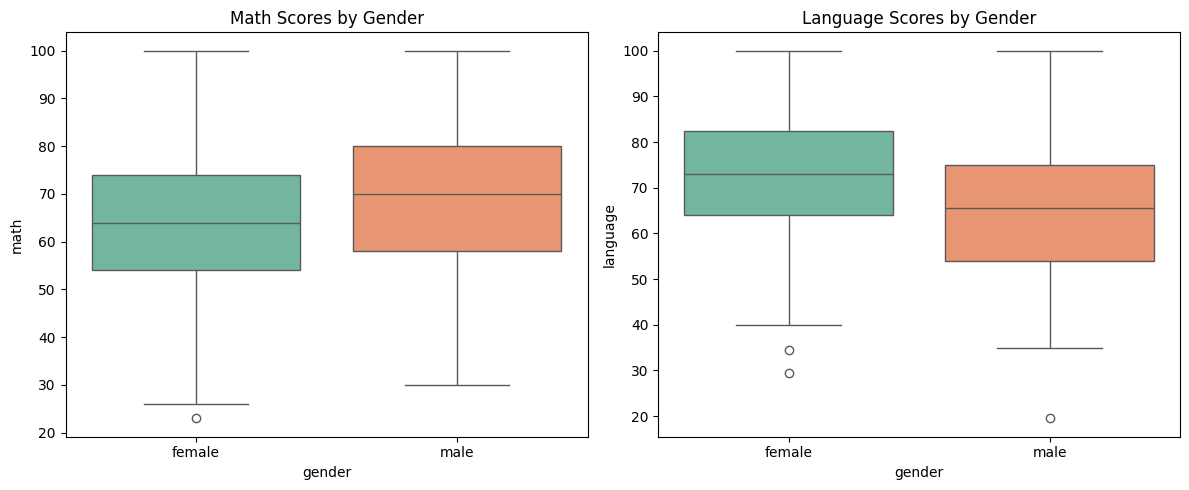

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

#statistical graphic (Boxplots)
plt.figure(figsize=(12, 5))

# Math scores by gender
plt.subplot(1, 2, 1)
sns.boxplot(x='gender', y='math', hue='gender', data=df_clean, palette='Set2', legend=False)
plt.title('Math Scores by Gender')

# Language scores by gender
plt.subplot(1, 2, 2)
sns.boxplot(x='gender', y='language', hue='gender', data=df_clean, palette='Set2', legend=False)
plt.title('Language Scores by Gender')
plt.tight_layout()
plt.show()

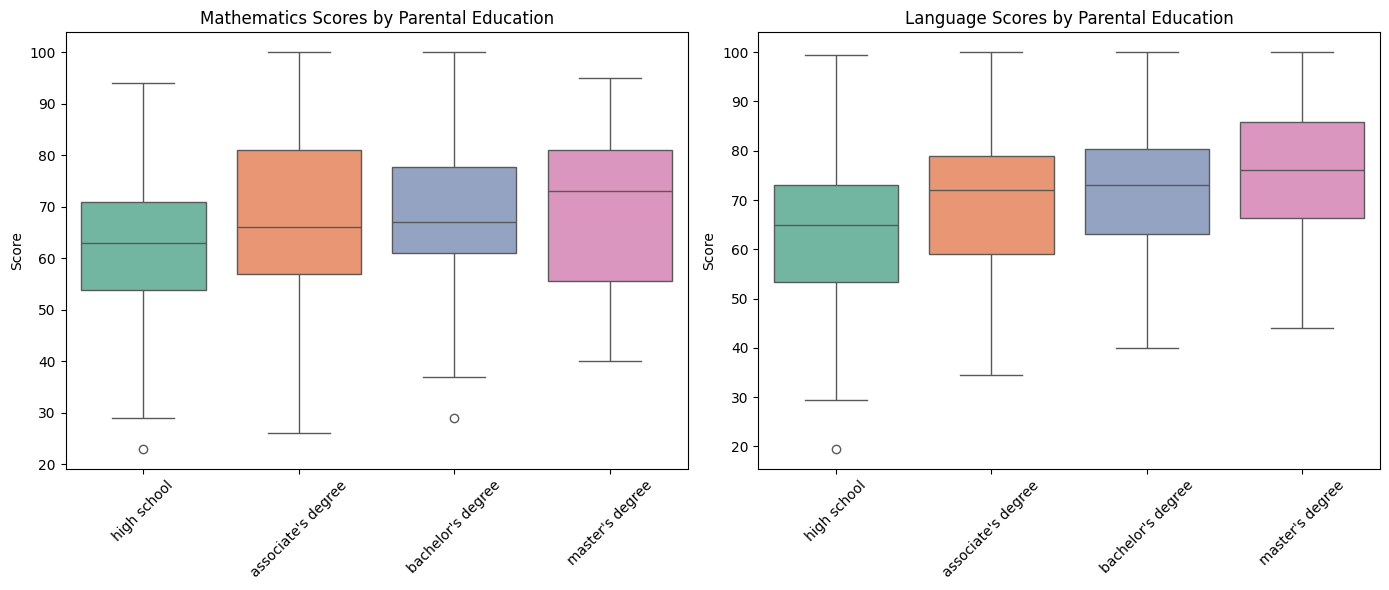

In [21]:
# Set up the figure size
plt.figure(figsize=(14, 6))

# Math scores by parental education
plt.subplot(1, 2, 1)
sns.boxplot(x='parental.level.of.education', y='math', hue='parental.level.of.education', data=df_clean, palette='Set2', legend=False)
plt.title('Mathematics Scores by Parental Education')
# We rotate the x-axis labels by 45 degrees so the long education names don't overlap!
plt.xticks(rotation=45) 
plt.ylabel('Score')
plt.xlabel('')

# Language scores by parental education
plt.subplot(1, 2, 2)
sns.boxplot(x='parental.level.of.education', y='language', hue='parental.level.of.education', data=df_clean, palette='Set2', legend=False)
plt.title('Language Scores by Parental Education')
plt.xticks(rotation=45)
plt.ylabel('Score')
plt.xlabel('')

# Make sure nothing overlaps
plt.tight_layout()

# Save the high-resolution image for your Word document
plt.savefig('education_boxplots.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

## 4. Hypothesis Testing: Gender Differences
**Research Question:** Is there a significant difference between male and female students in Math and Language?

**Method: Welch's Two-Sample t-test**
We use Welch's t-test as it does not assume equal variances between the two groups. 
The test statistic $t$ is calculated as:
$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$
* Null Hypothesis ($H_0$): $\mu_{male} = \mu_{female}$ (No difference in means)
* Significance Level ($\alpha$): 0.05

In [24]:
import scipy.stats as stats

# Isolate scores
math_m = df_clean[df_clean['gender'] == 'male']['math'].dropna()
math_f = df_clean[df_clean['gender'] == 'female']['math'].dropna()
lang_m = df_clean[df_clean['gender'] == 'male']['language'].dropna()
lang_f = df_clean[df_clean['gender'] == 'female']['language'].dropna()

# Perform Welch's t-test
t_math, p_math = stats.ttest_ind(math_m, math_f, equal_var=False)
t_lang, p_lang = stats.ttest_ind(lang_m, lang_f, equal_var=False)

print(f"Math T-test Result:     t = {t_math:.3f}, p-value = {p_math:.5e}")
print(f"Language T-test Result: t = {t_lang:.3f}, p-value = {p_lang:.5e}")

Math T-test Result:     t = 3.778, p-value = 1.77654e-04
Language T-test Result: t = -6.410, p-value = 3.46676e-10


## 5. Hypothesis Testing: Parental Education Differences
**Research Question:** Is there a difference in scores across parental education levels? Which groups differ?

**Method 1: One-Way ANOVA**
ANOVA compares the means across three or more independent groups. The F-statistic is the ratio of between-group variance to within-group variance.
* Null Hypothesis ($H_0$): $\mu_{HighSchool} = \mu_{Associates} = \mu_{Bachelors} = \mu_{Masters}$

**Method 2: Tukey's HSD (Honest Significant Difference)**
If the ANOVA is significant (p < 0.05), we run Tukey's HSD to perform pairwise comparisons and find exactly *which* education levels are significantly different from one another.

In [27]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Group data for ANOVA
groups_math = [group['math'].dropna().values for name, group in df_clean.groupby('parental.level.of.education')]
groups_lang = [group['language'].dropna().values for name, group in df_clean.groupby('parental.level.of.education')]

# Run ANOVA
f_math, p_anova_math = stats.f_oneway(*groups_math)
f_lang, p_anova_lang = stats.f_oneway(*groups_lang)

print(f"Math ANOVA Result:     F = {f_math:.3f}, p-value = {p_anova_math:.5e}")
print(f"Language ANOVA Result: F = {f_lang:.3f}, p-value = {p_anova_lang:.5e}\n")



Math ANOVA Result:     F = 6.223, p-value = 3.75089e-04
Language ANOVA Result: F = 14.241, p-value = 6.61786e-09



In [29]:
# Run Tukey HSD Post-Hoc Test
clean_data = df_clean.dropna(subset=['math', 'language', 'parental.level.of.education'])

print("--- Tukey HSD Post-Hoc Test for Mathematics ---")
tukey_math = pairwise_tukeyhsd(endog=clean_data['math'], groups=clean_data['parental.level.of.education'], alpha=0.05)
print(tukey_math)

print("\n--- Tukey HSD Post-Hoc Test for Language ---")
tukey_lang = pairwise_tukeyhsd(endog=clean_data['language'], groups=clean_data['parental.level.of.education'], alpha=0.05)
print(tukey_lang)

--- Tukey HSD Post-Hoc Test for Mathematics ---
            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------
associate's degree bachelor's degree   0.6226 0.9877  -4.2525  5.4977  False
associate's degree       high school    -5.57 0.0037  -9.7649 -1.3751   True
associate's degree   master's degree   1.9322 0.8217  -3.8102  7.6746  False
 bachelor's degree       high school  -6.1926 0.0079 -11.1802  -1.205   True
 bachelor's degree   master's degree   1.3096 0.9512   -5.035  7.6542  False
       high school   master's degree   7.5022 0.0055   1.6639 13.3404   True
----------------------------------------------------------------------------

--- Tukey HSD Post-Hoc Test for Language ---
            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower

## 6. Summary and Discussion
Based on the statistical evaluation:
1. **Gender:** The p-values for both t-tests are $< 0.05$. We reject the null hypotheses. Males score significantly higher in Mathematics, while females score significantly higher in Language.
2. **Education:** Both ANOVAs yield p-values $< 0.05$, proving parental education impacts scores. The Tukey HSD tests reveal that students whose parents have only a "high school" education score significantly lower in both subjects compared to students whose parents hold academic degrees. In Language, students with "master's degree" parents also scored significantly higher than those with "associate's degree" parents.